In [52]:
"""In this notebook, the goal is to explore and understand the structure and characteristics of the dataset
 before building any models. This includes visually inspecting images and comparing how they differ across cameras, 
 individuals, and processing methods. We will examine the distribution of labels (1–10) to check for imbalance, and 
 look for any inconsistencies or anomalies in the data such as mislabeled or corrupted images. Additionally, we will 
 begin to develop intuition about how image properties (e.g., brightness, contrast) may relate to the labels. This step 
 is critical for identifying potential sources of variability (camera differences, human differences, raw vs processed images) 
 and ensuring the data is clean, consistent, and suitable for modeling."""

'In this notebook, the goal is to explore and understand the structure and characteristics of the dataset\n before building any models. This includes visually inspecting images and comparing how they differ across cameras, \n individuals, and processing methods. We will examine the distribution of labels (1–10) to check for imbalance, and \n look for any inconsistencies or anomalies in the data such as mislabeled or corrupted images. Additionally, we will \n begin to develop intuition about how image properties (e.g., brightness, contrast) may relate to the labels. This step \n is critical for identifying potential sources of variability (camera differences, human differences, raw vs processed images) \n and ensuring the data is clean, consistent, and suitable for modeling.'

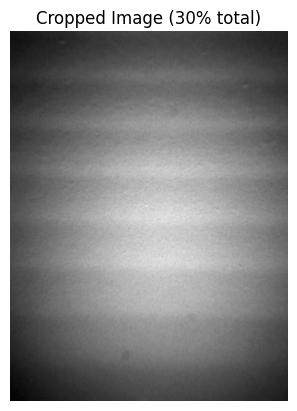

8081920
(3280, 2464)
(2464, 3280)
(2464, 3280)
527.903625096044
526.1715741068416
528.601053932742


In [83]:
# load as RGB (maybe I should just load as grayscale) image using pillow package - just try with the original images first

from PIL import Image
import os


img = Image.open("../data/raw/1/Leveling-1_GS-25-130_0degrees (1).png").convert("L")
img2 = Image.open("../data/raw/1/Leveling-1_GS-25-130_0degrees (2).png").convert("L")
img3 = Image.open("../data/raw/3/Leveling-3_GS-25-100 (1).png").convert("L")

img.show()

import numpy as np
import matplotlib.pyplot as plt

img_array = np.array(img)

h, w = img_array.shape

# amount to remove (15% from each side)
crop_h = int(0.15 * h)
crop_w = int(0.15 * w)

img_cropped = img_array[
    crop_h : h - crop_h,   # vertical (top + bottom)
    crop_w : w - crop_w    # horizontal (left + right)
]

# show image
import matplotlib.pyplot as plt

plt.imshow(img_cropped, cmap='gray')
plt.title("Cropped Image (30% total)")
plt.axis('off')
plt.show()

import numpy as np
img_array = np.array(img)
img_array2 = np.array(img2)
img_array3 = np.array(img3)

num_pixels = img_array.size
print(num_pixels)
print(img_array.shape)
print(img_array2.shape)
print(img_array3.shape)



# now we want to compute image-derived metrics 
# some image derived metrics: MSE and PSNR
# MSE is average of the squared differences between two images (pixel-by-pixel)
#here we are looking for a model that takes an image an outputs an average human rating

#we want to ask how much do pixels deviate from a perfectly uniform version of this image
# so we can take the mean of the image, and then computer the MSE between the image and the average


def compute_mse(img_array): #this function takes an array and computes the MSE
    mean_val = np.mean(img_array)
    mse = np.mean((img_array - mean_val) ** 2)
    return mse

mse1 = compute_mse(img_array)
mse2 = compute_mse(img_array2)
mse3 = compute_mse(img_array3)

print(mse1) #leveling 1
print(mse2) #leveling 1
print(mse3) #leveling 3


In [54]:
#based on these results, we can't see the pattern we want to, so lets create a scatter plot of all the images and see if we get a linear trend
#color the points by the leveling score


# load in all our images and labels into a list of tuples (label, filename, numpy array) so we can easily access them for plotting and modeling
# and also store the mse

import os
import numpy as np
from PIL import Image

def compute_mse(img_array):
    mean_val = np.mean(img_array)
    mse = np.mean((img_array - mean_val) ** 2)
    return mse

raw_data_dir = "../data/raw"

images = []   # list of (label, filename, numpy array, mse)

for label_folder in sorted(os.listdir(raw_data_dir), key=lambda x: int(x)):
    folder_path = os.path.join(raw_data_dir, label_folder)
    if not os.path.isdir(folder_path):
        continue
    
    label = int(label_folder)
    
    for filename in sorted(os.listdir(folder_path)):
        if filename.lower().endswith(".png"):
            img_path = os.path.join(folder_path, filename)
            
            img = Image.open(img_path).convert("L")
            img_array = np.array(img)
            
            mse = compute_mse(img_array)
            
            images.append((label, filename, img_array, mse))

print(f"Loaded {len(images)} images")
print(f"Example — label: {images[0][0]}, file: {images[0][1]}, MSE: {images[0][3]}")


Loaded 312 images
Example — label: 1, file: Leveling-1_GS-25-130_0degrees (1).png, MSE: 527.903625096044


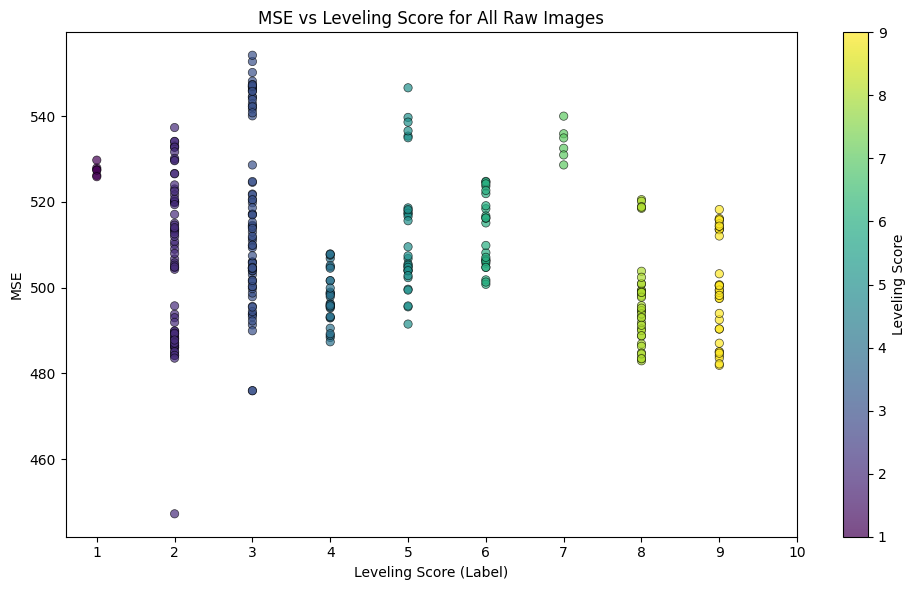

In [55]:
# create a scatter plot of MSE vs leveling score for all raw images, color the points by the leveling score

import matplotlib.pyplot as plt

labels = [item[0] for item in images]
mses   = [item[3] for item in images]

plt.figure(figsize=(10, 6))
scatter = plt.scatter(labels, mses, c=labels, cmap="viridis", alpha=0.7, edgecolors="k", linewidths=0.5)
plt.colorbar(scatter, label="Leveling Score")
plt.xlabel("Leveling Score (Label)")
plt.ylabel("MSE")
plt.title("MSE vs Leveling Score for All Raw Images")
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()


Average MSE by leveling score:
Label 1: 527.421
Label 2: 506.772
Label 3: 517.494
Label 4: 497.798
Label 5: 513.204
Label 6: 512.775
Label 7: 533.805
Label 8: 496.919
Label 9: 500.366


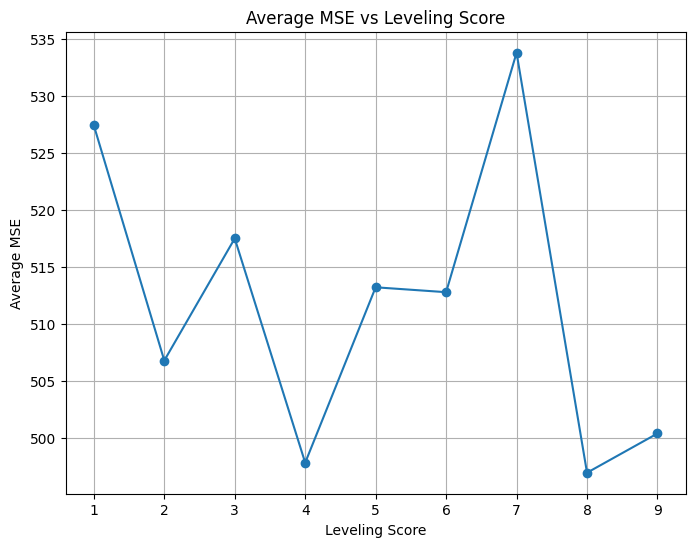

In [56]:
# compute the average MSE for each leveling score (1-10)

import numpy as np

avg_mse_by_label = {}
for label in range(1, 11):
    label_mses = [item[3] for item in images if item[0] == label]
    if len(label_mses) > 0:
        avg_mse_by_label[label] = float(np.mean(label_mses))

print("Average MSE by leveling score:")
for label in sorted(avg_mse_by_label):
    print(f"Label {label}: {avg_mse_by_label[label]:.3f}")


# plot the average MSE by leveling score as a line plot
import matplotlib.pyplot as plt

# sort labels to keep order correct
labels = sorted(avg_mse_by_label.keys())
avg_mse_values = [avg_mse_by_label[label] for label in labels]

plt.figure(figsize=(8, 6))

plt.plot(labels, avg_mse_values, marker='o', linestyle='-')

plt.xlabel("Leveling Score")
plt.ylabel("Average MSE")
plt.title("Average MSE vs Leveling Score")

plt.xticks(labels)
plt.grid(True)

plt.show()


In [57]:
# based on the above graph we can see that MSE isnt capturing what humans see, so we need to think about a different metric that we could use
# one metric we can try is edge strength -> measures how strong the changes in brightness are across the image

from scipy import ndimage
import numpy as np

#function that takes an numpy array and computes the edge strength using the Sobel operator
def compute_edge_strength(img_array):
    dx = ndimage.sobel(img_array, axis=1)   # horizontal direction differences
    edge_strength = np.mean(np.abs(dx))
    return edge_strength

# compute edge strength for all images and add to our list of tuples called images
images_with_edge = []

for item in images:
    label, filename, img_array, mse = item[:4]
    edge_strength = compute_edge_strength(img_array)
    images_with_edge.append((label, filename, img_array, mse, edge_strength))

images = images_with_edge

print(f"Updated {len(images)} images with edge strength")
print(f"Example tuple format: (label, filename, img_array, mse, edge_strength)")
print(f"Example edge strength: {images[0][4]:.3f}")



Updated 312 images with edge strength
Example tuple format: (label, filename, img_array, mse, edge_strength)
Example edge strength: 102.435


In [58]:
print(images[0])

(1, 'Leveling-1_GS-25-130_0degrees (1).png', array([[24, 24, 24, ..., 34, 34, 34],
       [24, 24, 24, ..., 33, 33, 34],
       [24, 24, 24, ..., 33, 33, 33],
       ...,
       [31, 31, 31, ..., 38, 37, 37],
       [31, 31, 31, ..., 38, 37, 37],
       [33, 31, 31, ..., 39, 38, 38]], shape=(3280, 2464), dtype=uint8), np.float64(527.903625096044), np.float64(102.4349946547355))


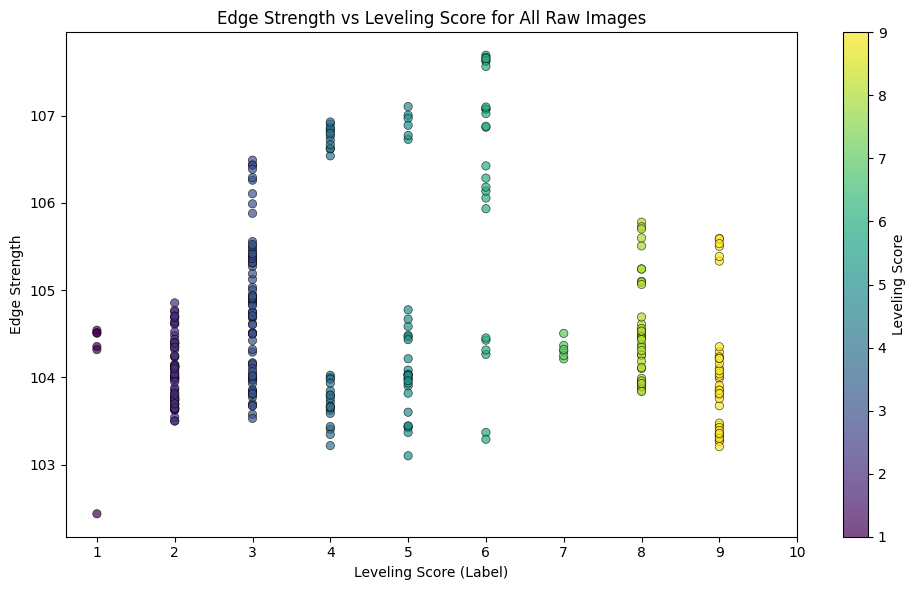

In [59]:
# create a scatter plot of the edge strength vs leveling score for all raw images, color the points by the leveling score

import matplotlib.pyplot as plt

labels = [item[0] for item in images]

# If edge strength is already stored in tuple index 4, use it.
# Otherwise compute it from the image array at tuple index 2.
edge_strengths = []
for item in images:
    if len(item) >= 5:
        edge_strengths.append(item[4])
    else:
        edge_strengths.append(compute_edge_strength(item[2]))

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    labels,
    edge_strengths,
    c=labels,
    cmap="viridis",
    alpha=0.7,
    edgecolors="k",
    linewidths=0.5,
)

plt.colorbar(scatter, label="Leveling Score")
plt.xlabel("Leveling Score (Label)")
plt.ylabel("Edge Strength")
plt.title("Edge Strength vs Leveling Score for All Raw Images")
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()


In [ ]:
# we can see from the figure above that edge strength also isnt capturing what humans see, so maybe lets try using the flat images

import sys

sys.path.append(os.path.abspath(".."))

from src.data import load_images

images = load_images("flat") #this gives us our images as a list of tuples (label, filename, numpy array) 

Loaded 312 images from 'flat'


In [63]:
# continue from above step, we want to compute MSE on the flat images

#compute MSE and add it to list of images
from src.features import append_mse_to_images

images = append_mse_to_images(images)


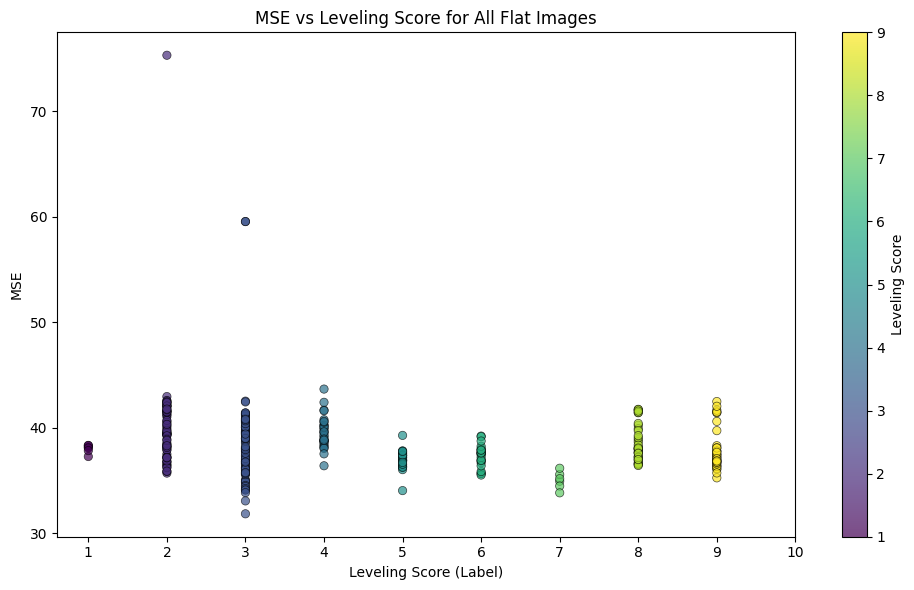

In [ ]:

# create scatter plot of MSE vs leveling score for all flat images, color the points by the leveling score

import matplotlib.pyplot as plt

labels = [item[0] for item in images]
mses   = [item[3] for item in images]

plt.figure(figsize=(10, 6))
scatter = plt.scatter(labels, mses, c=labels, cmap="viridis", alpha=0.7, edgecolors="k", linewidths=0.5)
plt.colorbar(scatter, label="Leveling Score")
plt.xlabel("Leveling Score (Label)")
plt.ylabel("MSE")
plt.title("MSE vs Leveling Score for All Flat Images")
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()


In [ ]:
# based on the above graph, we can see MSE using the flat images wont work either

In [ ]:
# now lets try the flat images with the edge strength metric instead of MSE and see if that captures what humans see better than the raw images with MSE or edge strength
images = load_images("flat")

from src.features import compute_edge_strength
from src.features import append_edge_strength_to_images
images = append_edge_strength_to_images(images)


Loaded 312 images from 'flat'
(1, 'Leveling-1_GS-25-130_0degrees_flat (1).png', array([[103, 102,  97, ..., 102, 102, 106],
       [103,  99,  97, ..., 102, 102, 106],
       [103,  98,  98, ..., 102, 102, 106],
       ...,
       [ 94,  94,  95, ..., 111, 112, 112],
       [ 94,  94,  96, ..., 112, 114, 114],
       [ 94,  94,  94, ..., 113, 114, 122]],
      shape=(2464, 3280), dtype=uint8))
(1, 'Leveling-1_GS-25-130_0degrees_flat (1).png', array([[103, 102,  97, ..., 102, 102, 106],
       [103,  99,  97, ..., 102, 102, 106],
       [103,  98,  98, ..., 102, 102, 106],
       ...,
       [ 94,  94,  95, ..., 111, 112, 112],
       [ 94,  94,  96, ..., 112, 114, 114],
       [ 94,  94,  94, ..., 113, 114, 122]],
      shape=(2464, 3280), dtype=uint8), np.float64(111.921648321191))


(1, 'Leveling-1_GS-25-130_0degrees_flat (1).png', array([[103, 102,  97, ..., 102, 102, 106],
       [103,  99,  97, ..., 102, 102, 106],
       [103,  98,  98, ..., 102, 102, 106],
       ...,
       [ 94,  94,  95, ..., 111, 112, 112],
       [ 94,  94,  96, ..., 112, 114, 114],
       [ 94,  94,  94, ..., 113, 114, 122]],
      shape=(2464, 3280), dtype=uint8), np.float64(111.921648321191))


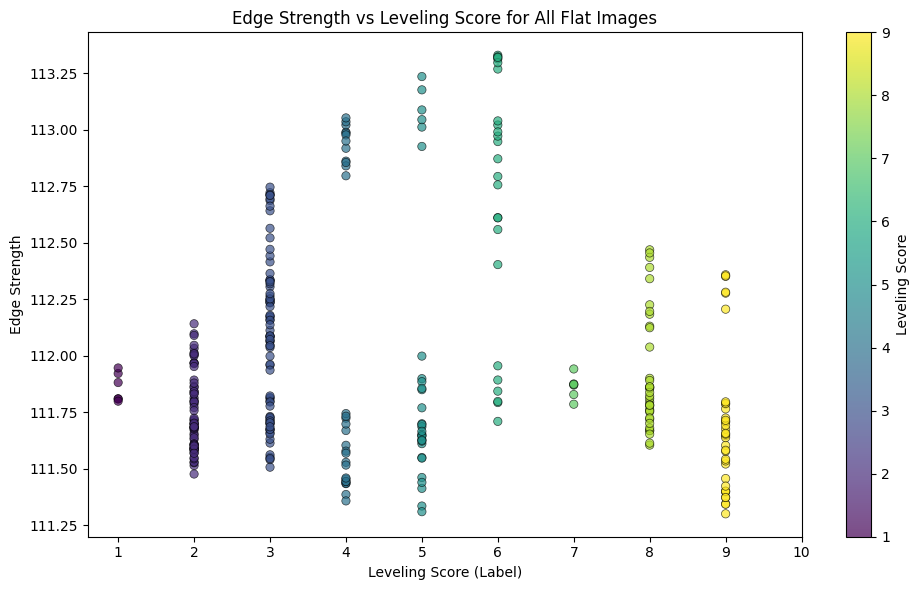

In [75]:
# create scatter plot
import matplotlib.pyplot as plt

print(images[0]) # check the format of the images list to make sure we have the edge strength in the right place

labels = [item[0] for item in images]
edge_strengths = [item[3] for item in images]

plt.figure(figsize=(10, 6))
scatter = plt.scatter(labels, edge_strengths, c=labels, cmap="viridis", alpha=0.7, edgecolors="k", linewidths=0.5)
plt.colorbar(scatter, label="Leveling Score")
plt.xlabel("Leveling Score (Label)")
plt.ylabel("Edge Strength")
plt.title("Edge Strength vs Leveling Score for All Flat Images")
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

In [77]:
# we can see again for flat and raw images, edge strength and MSE arent capturing what humans see
# try some different metrics and look at correlation coefficient based on the grayscale raw images

images = load_images("raw")


Loaded 312 images from 'raw'


In [76]:
# compute several image metrics and show correlation with label

import numpy as np
from scipy import ndimage
from scipy.stats import pearsonr, spearmanr

# If images is not loaded yet, load raw images.
if "images" not in globals() or len(images) == 0:
    images = load_images("raw")


def compute_metrics(img_array):
    arr = img_array.astype(np.float32)

    mean_intensity = float(np.mean(arr))
    std_intensity = float(np.std(arr))
    rms_contrast = std_intensity

    # MSE to image mean (same concept you already used)
    mean_val = np.mean(arr)
    mse_to_mean = float(np.mean((arr - mean_val) ** 2))

    # Edge/gradient based metrics
    sobel_x = ndimage.sobel(arr, axis=1)
    sobel_y = ndimage.sobel(arr, axis=0)
    grad_mag = np.hypot(sobel_x, sobel_y)

    edge_strength = float(np.mean(np.abs(sobel_x)))
    tenengrad = float(np.mean(grad_mag ** 2))

    # Focus/texture metric
    lap = ndimage.laplace(arr)
    laplacian_var = float(np.var(lap))

    # Entropy from 256-bin histogram
    hist, _ = np.histogram(arr, bins=256, range=(0, 255), density=True)
    hist = hist[hist > 0]
    entropy = float(-np.sum(hist * np.log2(hist)))

    return {
        "mean_intensity": mean_intensity,
        "std_intensity": std_intensity,
        "rms_contrast": rms_contrast,
        "mse_to_mean": mse_to_mean,
        "edge_strength": edge_strength,
        "tenengrad": tenengrad,
        "laplacian_var": laplacian_var,
        "entropy": entropy,
    }


labels = np.array([item[0] for item in images], dtype=np.float32)

metric_names = [
    "mean_intensity",
    "std_intensity",
    "rms_contrast",
    "mse_to_mean",
    "edge_strength",
    "tenengrad",
    "laplacian_var",
    "entropy",
]

metric_values = {name: [] for name in metric_names}
for item in images:
    metrics = compute_metrics(item[2])
    for name in metric_names:
        metric_values[name].append(metrics[name])

print("Correlation with label (higher absolute value means stronger monotonic/linear relation):")
print("-" * 84)
print(f"{'Metric':<18} {'Pearson r':>12} {'p-value':>12} {'Spearman rho':>14} {'p-value':>12}")
print("-" * 84)

for name in metric_names:
    vals = np.array(metric_values[name], dtype=np.float32)
    pr, pp = pearsonr(labels, vals)
    sr, sp = spearmanr(labels, vals)
    print(f"{name:<18} {pr:>12.3f} {pp:>12.3g} {sr:>14.3f} {sp:>12.3g}")


Correlation with label (higher absolute value means stronger monotonic/linear relation):
------------------------------------------------------------------------------------
Metric                Pearson r      p-value   Spearman rho      p-value
------------------------------------------------------------------------------------
mean_intensity           -0.300     6.25e-08         -0.283     3.79e-07
std_intensity            -0.186     0.000985         -0.255     5.13e-06
rms_contrast             -0.186     0.000985         -0.255     5.13e-06
mse_to_mean              -0.180      0.00141         -0.255     5.13e-06
edge_strength            -0.050        0.375         -0.023         0.69
tenengrad                -0.033        0.556         -0.035        0.539
laplacian_var            -0.203     0.000316         -0.185      0.00101
entropy                  -0.467     2.47e-18         -0.583     8.96e-30


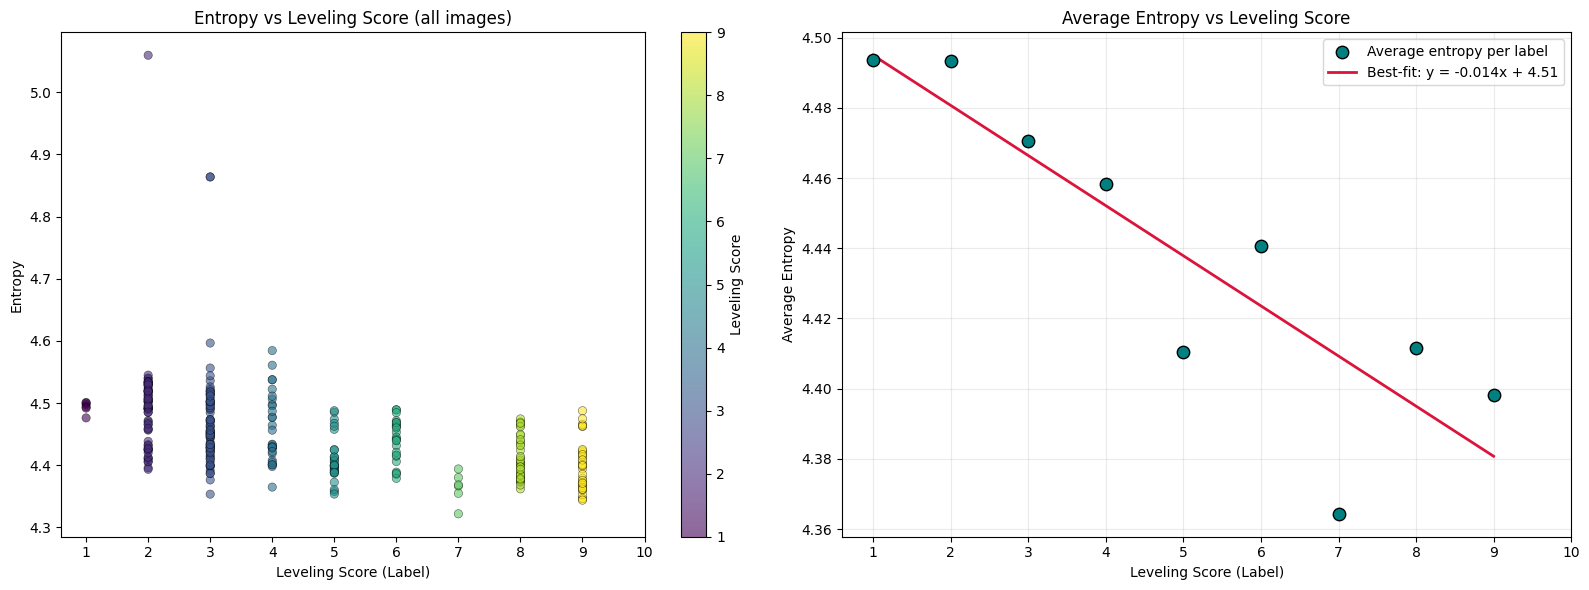

Pearson r:    -0.467  (p=2.47e-18)
Spearman rho: -0.583  (p=8.96e-30)


In [78]:
# visualize entropy vs label: scatter plot of every image + average per label

import matplotlib.pyplot as plt
import numpy as np

entropies = np.array(metric_values["entropy"])

# average entropy per label
avg_entropy_by_label = {}
for lbl in range(1, 11):
    vals = entropies[labels == lbl]
    if len(vals) > 0:
        avg_entropy_by_label[lbl] = float(np.mean(vals))

x_avg = np.array(sorted(avg_entropy_by_label.keys()))
y_avg = np.array([avg_entropy_by_label[l] for l in x_avg])

# best-fit line through the averages
m, b = np.polyfit(x_avg, y_avg, 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- left: all points ---
sc = axes[0].scatter(labels, entropies, c=labels, cmap="viridis", alpha=0.6, edgecolors="k", linewidths=0.4)
plt.colorbar(sc, ax=axes[0], label="Leveling Score")
axes[0].set_xlabel("Leveling Score (Label)")
axes[0].set_ylabel("Entropy")
axes[0].set_title("Entropy vs Leveling Score (all images)")
axes[0].set_xticks(range(1, 11))

# --- right: average per label + best-fit line ---
axes[1].scatter(x_avg, y_avg, s=80, color="teal", edgecolors="black", zorder=3, label="Average entropy per label")
axes[1].plot(x_avg, m * x_avg + b, color="crimson", linewidth=2, label=f"Best-fit: y = {m:.3f}x + {b:.2f}")
axes[1].set_xlabel("Leveling Score (Label)")
axes[1].set_ylabel("Average Entropy")
axes[1].set_title("Average Entropy vs Leveling Score")
axes[1].set_xticks(range(1, 11))
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

from scipy.stats import pearsonr, spearmanr
pr, pp = pearsonr(labels, entropies)
sr, sp = spearmanr(labels, entropies)
print(f"Pearson r:    {pr:.3f}  (p={pp:.3g})")
print(f"Spearman rho: {sr:.3f}  (p={sp:.3g})")


In [93]:
# now lets try to crop the images to see if that helps the metrics
import sys
import importlib

sys.path.append(os.path.abspath(".."))

import src.data as data_module
importlib.reload(data_module)

images = data_module.load_images_optional_crop("flat", crop_fraction=0.40)
print(f"Cropped image shape: {images[0][2].shape}")

#now lets rerun the metrics on the cropped images and see if we get a better correlation with the labels

# compute several image metrics and show correlation with label

import numpy as np
from scipy import ndimage
from scipy.stats import pearsonr, spearmanr


def compute_metrics(img_array):
    arr = img_array.astype(np.float32)

    mean_intensity = float(np.mean(arr))
    std_intensity = float(np.std(arr))
    rms_contrast = std_intensity

    # MSE to image mean (same concept you already used)
    mean_val = np.mean(arr)
    mse_to_mean = float(np.mean((arr - mean_val) ** 2))

    # Edge/gradient based metrics
    sobel_x = ndimage.sobel(arr, axis=1)
    sobel_y = ndimage.sobel(arr, axis=0)
    grad_mag = np.hypot(sobel_x, sobel_y)

    edge_strength = float(np.mean(np.abs(sobel_x)))
    tenengrad = float(np.mean(grad_mag ** 2))

    # Focus/texture metric
    lap = ndimage.laplace(arr)
    laplacian_var = float(np.var(lap))

    # Entropy from 256-bin histogram
    hist, _ = np.histogram(arr, bins=256, range=(0, 255), density=True)
    hist = hist[hist > 0]
    entropy = float(-np.sum(hist * np.log2(hist)))

    return {
        "mean_intensity": mean_intensity,
        "std_intensity": std_intensity,
        "rms_contrast": rms_contrast,
        "mse_to_mean": mse_to_mean,
        "edge_strength": edge_strength,
        "tenengrad": tenengrad,
        "laplacian_var": laplacian_var,
        "entropy": entropy,
    }


labels = np.array([item[0] for item in images], dtype=np.float32)

metric_names = [
    "mean_intensity",
    "std_intensity",
    "rms_contrast",
    "mse_to_mean",
    "edge_strength",
    "tenengrad",
    "laplacian_var",
    "entropy",
]

metric_values = {name: [] for name in metric_names}
for item in images:
    metrics = compute_metrics(item[2])
    for name in metric_names:
        metric_values[name].append(metrics[name])

print("Correlation with label (higher absolute value means stronger monotonic/linear relation):")
print("-" * 84)
print(f"{'Metric':<18} {'Pearson r':>12} {'p-value':>12} {'Spearman rho':>14} {'p-value':>12}")
print("-" * 84)

for name in metric_names:
    vals = np.array(metric_values[name], dtype=np.float32)
    pr, pp = pearsonr(labels, vals)
    sr, sp = spearmanr(labels, vals)
    print(f"{name:<18} {pr:>12.3f} {pp:>12.3g} {sr:>14.3f} {sp:>12.3g}")


Loaded 312 images from 'flat' (cropping=ON)
Cropped image shape: (1480, 1968)
Correlation with label (higher absolute value means stronger monotonic/linear relation):
------------------------------------------------------------------------------------
Metric                Pearson r      p-value   Spearman rho      p-value
------------------------------------------------------------------------------------
mean_intensity           -0.266     1.93e-06         -0.235     2.79e-05
std_intensity            -0.633      2.1e-36         -0.643     7.35e-38
rms_contrast             -0.633      2.1e-36         -0.643     7.35e-38
mse_to_mean              -0.623     5.29e-35         -0.643     7.35e-38
edge_strength            -0.009         0.88          0.010        0.859
tenengrad                -0.045        0.426         -0.030        0.599
laplacian_var            -0.175      0.00195         -0.130       0.0214
entropy                  -0.670     4.56e-42         -0.652     4.33e-39


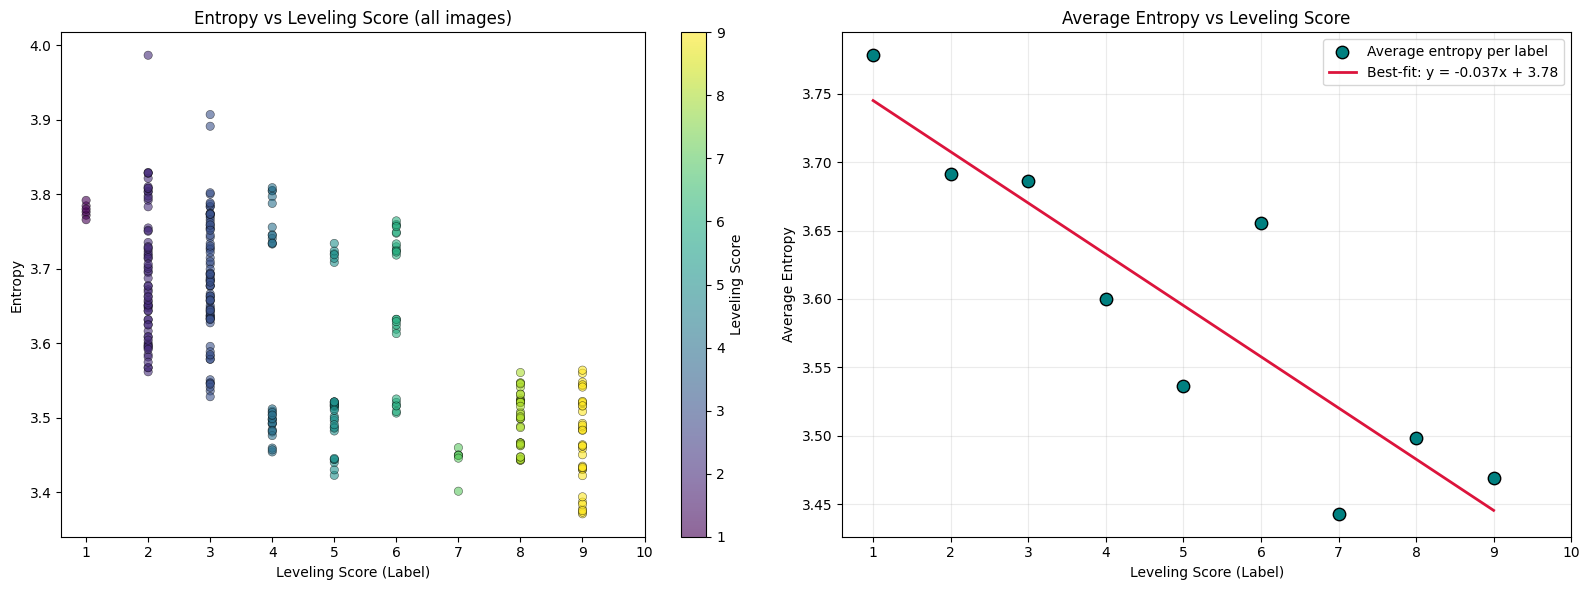

Pearson r:    -0.670  (p=4.56e-42)
Spearman rho: -0.652  (p=4.33e-39)


In [94]:
# visualize entropy vs label: scatter plot of every image + average per label

import matplotlib.pyplot as plt
import numpy as np

entropies = np.array(metric_values["entropy"])

# average entropy per label
avg_entropy_by_label = {}
for lbl in range(1, 11):
    vals = entropies[labels == lbl]
    if len(vals) > 0:
        avg_entropy_by_label[lbl] = float(np.mean(vals))

x_avg = np.array(sorted(avg_entropy_by_label.keys()))
y_avg = np.array([avg_entropy_by_label[l] for l in x_avg])

# best-fit line through the averages
m, b = np.polyfit(x_avg, y_avg, 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- left: all points ---
sc = axes[0].scatter(labels, entropies, c=labels, cmap="viridis", alpha=0.6, edgecolors="k", linewidths=0.4)
plt.colorbar(sc, ax=axes[0], label="Leveling Score")
axes[0].set_xlabel("Leveling Score (Label)")
axes[0].set_ylabel("Entropy")
axes[0].set_title("Entropy vs Leveling Score (all images)")
axes[0].set_xticks(range(1, 11))

# --- right: average per label + best-fit line ---
axes[1].scatter(x_avg, y_avg, s=80, color="teal", edgecolors="black", zorder=3, label="Average entropy per label")
axes[1].plot(x_avg, m * x_avg + b, color="crimson", linewidth=2, label=f"Best-fit: y = {m:.3f}x + {b:.2f}")
axes[1].set_xlabel("Leveling Score (Label)")
axes[1].set_ylabel("Average Entropy")
axes[1].set_title("Average Entropy vs Leveling Score")
axes[1].set_xticks(range(1, 11))
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

from scipy.stats import pearsonr, spearmanr
pr, pp = pearsonr(labels, entropies)
sr, sp = spearmanr(labels, entropies)
print(f"Pearson r:    {pr:.3f}  (p={pp:.3g})")
print(f"Spearman rho: {sr:.3f}  (p={sp:.3g})")


Loaded 312 images from 'flat' (cropping=ON)


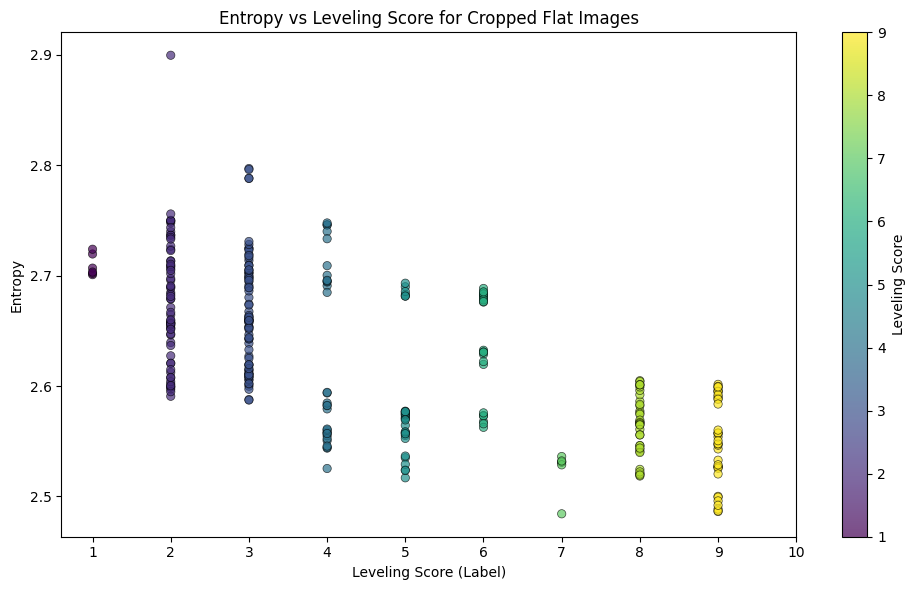

In [5]:
# try the pipeline using flat images, .30% cropped

import sys
import os
import importlib

sys.path.append(os.path.abspath(".."))

from src.data import load_images_optional_crop
from src.features import append_entropy_to_images


#load images
images = load_images_optional_crop("flat", crop_fraction=0.30)


#compute entropy of the images and add to the list of tuples
images = append_entropy_to_images(images)

#plot entropy vs label for the cropped flat images
import matplotlib.pyplot as plt
labels = [item[0] for item in images]
entropies = [item[3] for item in images]
plt.figure(figsize=(10, 6))
scatter = plt.scatter(labels, entropies, c=labels, cmap="viridis", alpha=0.7, edgecolors="k", linewidths=0.5)
plt.colorbar(scatter, label="Leveling Score")
plt.xlabel("Leveling Score (Label)")
plt.ylabel("Entropy")
plt.title("Entropy vs Leveling Score for Cropped Flat Images")
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()


In [7]:
# we then need to break the data into an 80/20 train test split (could do cross validation here and make sure class
#ratios are the same)


import numpy as np

X = np.array([[item[3]] for item in images])  # entropy as feature
y = np.array([item[0] for item in images])    # labels (1–9)


# get the data into an 80/20 train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,       # THIS is what keeps classes balanced
    random_state=42   # ensures reproducibility
)

#train the model
# we should use a linear regression model from sklearn (from sklearn.linear_model import LinearRegression)

from sklearn.linear_model import LinearRegression

# create model
model = LinearRegression()

# train (fit) the model
model.fit(X_train, y_train)

# make predictions
y_pred = model.predict(X_test)

#evaluate performance using MAE

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)


MAE: 1.6344502622915487


In [6]:
# now lets look at local entropy (computes entropy in small patches) and see how that goes
import sys
import os
import importlib

sys.path.append(os.path.abspath(".."))
from src.data import load_images_optional_crop

#load images
images = load_images_optional_crop("flat", crop_fraction=0.30)

Loaded 312 images from 'flat' (cropping=ON)


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

from skimage.filters.rank import entropy
from skimage.morphology import disk


def compute_local_entropy_features(img_array, radius=5):
    """
    Computes sliding window entropy and extracts summary features
    """
    img_uint8 = img_array.astype(np.uint8)

    ent_map = entropy(img_uint8, disk(radius))

    return {
        "local_entropy_mean": np.mean(ent_map),
        "local_entropy_std": np.std(ent_map),
        "local_entropy_max": np.max(ent_map)
    }

def compute_patch_entropy_features(img_array, patch_size=64):
    """
    Computes entropy on patches and extracts summary stats
    """
    h, w = img_array.shape
    
    entropies = []

    for i in range(0, h, patch_size):
        for j in range(0, w, patch_size):
            patch = img_array[i:i+patch_size, j:j+patch_size]

            if patch.shape[0] < patch_size or patch.shape[1] < patch_size:
                continue

            pixels = patch.flatten()
            hist, _ = np.histogram(pixels, bins=256, range=(0,256), density=True)
            hist = hist[hist > 0]

            ent = -np.sum(hist * np.log(hist))
            entropies.append(ent)

    entropies = np.array(entropies)

    return {
        "patch_entropy_mean": np.mean(entropies),
        "patch_entropy_std": np.std(entropies),
        "patch_entropy_max": np.max(entropies)
    }

feature_results = []

for label, filename, img_array in images:
    
    # ✅ downsample image (huge speedup)
    img_array = img_array[::4, ::4]
    
    local_feats = compute_local_entropy_features(img_array)
    patch_feats = compute_patch_entropy_features(img_array)
    
    combined = {
        "label": label,
        **local_feats,
        **patch_feats
    }
    
    feature_results.append(combined)


In [13]:
# extract labels
labels = np.array([item["label"] for item in feature_results])

# get feature names
feature_names = list(feature_results[0].keys())
feature_names.remove("label")

# build feature arrays
feature_matrix = {
    name: np.array([item[name] for item in feature_results])
    for name in feature_names
}

print("Correlation with label")
print("-" * 80)
print(f"{'Metric':<30}{'Pearson r':>12}{'Spearman rho':>18}")

for name in feature_names:
    vals = feature_matrix[name]
    
    pearson_r, _ = pearsonr(vals, labels)
    spearman_rho, _ = spearmanr(vals, labels)
    
    print(f"{name:<30}{pearson_r:>12.3f}{spearman_rho:>18.3f}")

Correlation with label
--------------------------------------------------------------------------------
Metric                           Pearson r      Spearman rho
local_entropy_mean                  -0.021            -0.054
local_entropy_std                    0.079             0.089
local_entropy_max                   -0.033             0.033
patch_entropy_mean                  -0.693            -0.661
patch_entropy_std                   -0.240            -0.275
patch_entropy_max                   -0.546            -0.544


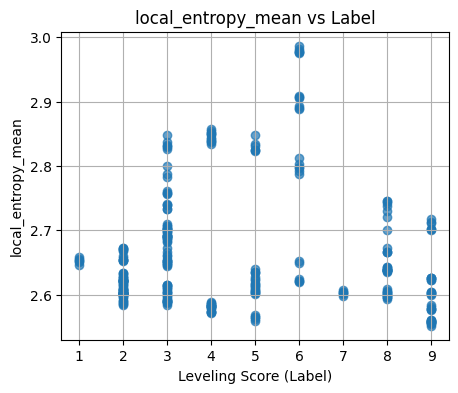

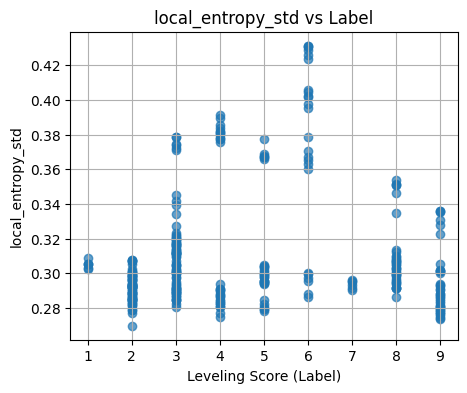

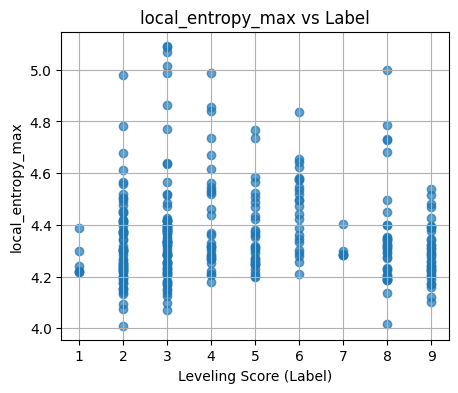

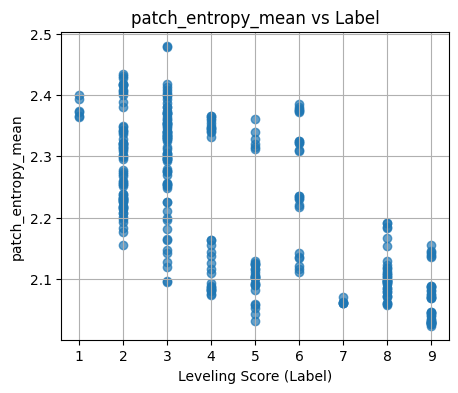

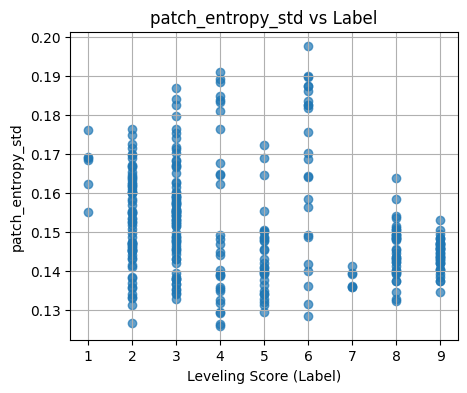

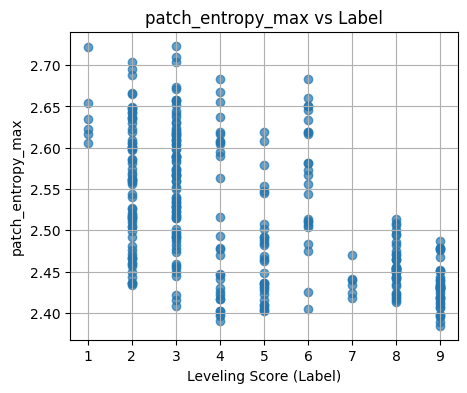

In [14]:
for name in feature_names:
    plt.figure(figsize=(5, 4))
    plt.scatter(labels, feature_matrix[name], alpha=0.7)
    
    plt.xlabel("Leveling Score (Label)")
    plt.ylabel(name)
    plt.title(f"{name} vs Label")
    plt.grid(True)
    
    plt.show()


In [17]:
def compute_global_entropy(img_array):
    pixels = img_array.flatten()
    hist, _ = np.histogram(pixels, bins=256, range=(0,256), density=True)
    hist = hist[hist > 0]
    return -np.sum(hist * np.log(hist))

global_entropy = []

for label, filename, img_array in images:
    img_array = img_array[::4, ::4]
    global_entropy.append(compute_global_entropy(img_array))

global_entropy = np.array(global_entropy)

# correlations
p, _ = pearsonr(global_entropy, labels)
s, _ = spearmanr(global_entropy, labels)

print("\nGlobal entropy comparison:")
print(f"Pearson: {p:.3f}")
print(f"Spearman: {s:.3f}")



Global entropy comparison:
Pearson: -0.658
Spearman: -0.671


In [ ]:
# based on the above results, we can see that local entropy metrics werent better than global metrics

In [19]:
import sys
import os
import importlib

sys.path.append(os.path.abspath(".."))
from src.data import load_images_optional_crop

#load images
images = load_images_optional_crop("flat", crop_fraction=0.30)

Loaded 312 images from 'flat' (cropping=ON)


Correlation with label
--------------------------------------------------------------------------------
Metric                           Pearson r      Spearman rho
fft_total_energy                    -0.030            -0.028
fft_high_freq_energy                 0.022             0.051
fft_max_peak                        -0.396            -0.348
fft_1d_peak                         -0.768            -0.794
fft_1d_energy                       -0.701            -0.837


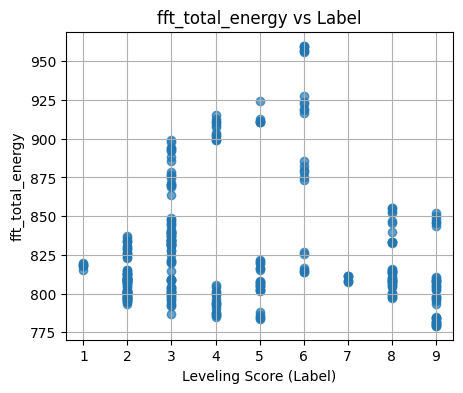

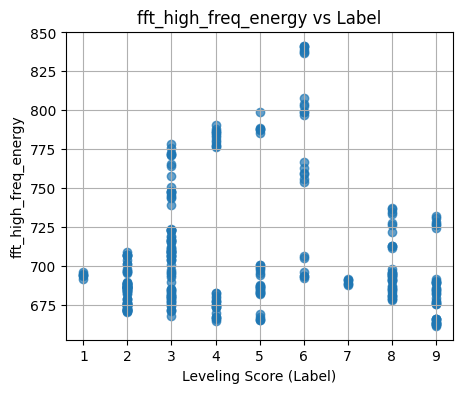

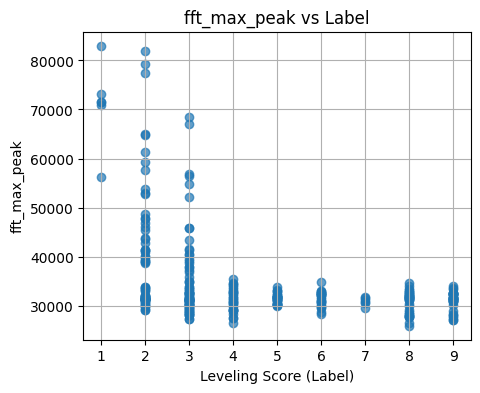

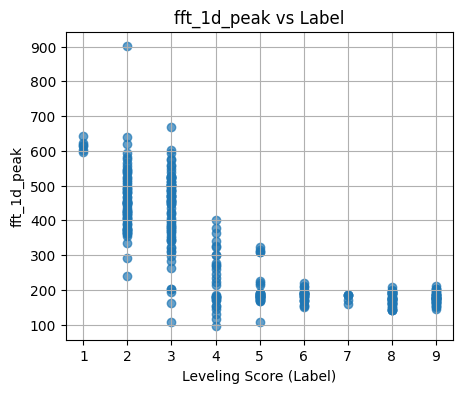

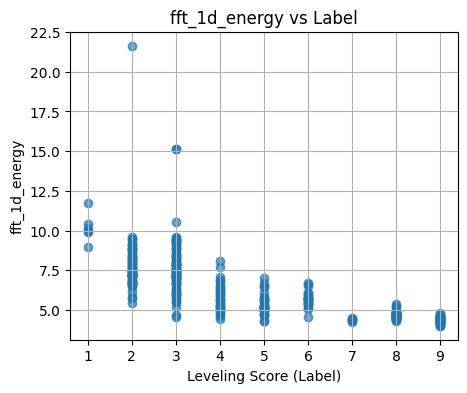

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# -------------------------
# FFT FEATURE FUNCTION
# -------------------------
def compute_fft_features(img_array):
    """
    Computes FFT-based features capturing texture + groove structure
    """

    # ✅ downsample for speed
    img = img_array[::4, ::4].astype(float)

    # --- 2D FFT ---
    f = np.fft.fft2(img)
    f_shift = np.fft.fftshift(f)
    magnitude = np.abs(f_shift)

    h, w = magnitude.shape
    ch, cw = h // 2, w // 2

    # total energy
    fft_total_energy = np.mean(magnitude)

    # remove low-frequency center (important!)
    mask = np.ones_like(magnitude)
    mask[ch-10:ch+10, cw-10:cw+10] = 0
    high_freq = magnitude * mask

    fft_high_freq_energy = np.mean(high_freq)
    fft_max_peak = np.max(high_freq)

    # --- 1D FFT along grooves (average rows) ---
    profile = img.mean(axis=0)  # collapse image → 1D signal

    fft_1d = np.fft.fft(profile)
    mag_1d = np.abs(fft_1d)

    # ignore zero-frequency (DC component)
    mag_1d[0] = 0

    fft_1d_peak = np.max(mag_1d)
    fft_1d_energy = np.mean(mag_1d)

    return {
        "fft_total_energy": fft_total_energy,
        "fft_high_freq_energy": fft_high_freq_energy,
        "fft_max_peak": fft_max_peak,
        "fft_1d_peak": fft_1d_peak,
        "fft_1d_energy": fft_1d_energy
    }


# -------------------------
# RUN FEATURE EXTRACTION
# -------------------------
feature_results = []

for label, filename, img_array in images:

    fft_feats = compute_fft_features(img_array)

    combined = {
        "label": label,
        **fft_feats
    }

    feature_results.append(combined)


# -------------------------
# EXTRACT ARRAYS
# -------------------------
labels = np.array([item["label"] for item in feature_results])

feature_names = list(feature_results[0].keys())
feature_names.remove("label")

feature_matrix = {
    name: np.array([item[name] for item in feature_results])
    for name in feature_names
}


# -------------------------
# CORRELATION TABLE
# -------------------------
print("Correlation with label")
print("-" * 80)
print(f"{'Metric':<30}{'Pearson r':>12}{'Spearman rho':>18}")

for name in feature_names:
    vals = feature_matrix[name]
    
    pearson_r, _ = pearsonr(vals, labels)
    spearman_rho, _ = spearmanr(vals, labels)
    
    print(f"{name:<30}{pearson_r:>12.3f}{spearman_rho:>18.3f}")


# -------------------------
# PLOTS
# -------------------------
for name in feature_names:
    plt.figure(figsize=(5,4))
    plt.scatter(labels, feature_matrix[name], alpha=0.7)

    plt.xlabel("Leveling Score (Label)")
    plt.ylabel(name)
    plt.title(f"{name} vs Label")
    plt.grid(True)

    plt.show()

In [ ]:
# based on the above results, fft_1d_energy is the best so far, better than entropy

In [ ]:
# the above graphs look curved, so we will try a nonlinear model and see if that improves things

In [25]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

def train_polynomial_model(X_train, y_train, degree=2):
    """
    Trains a polynomial regression model.

    Returns:
        model, polynomial transformer
    """

    # create polynomial feature transformer
    poly = PolynomialFeatures(degree=degree)

    # transform X into polynomial space
    X_train_poly = poly.fit_transform(X_train)

    # train linear model on transformed data
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    return model, poly


#load images
images = load_images_optional_crop("flat", crop_fraction=0.30)

#compute fft_1d_energy and append to images
images = append_fft_1d_energy_to_images(images)

Loaded 312 images from 'flat' (cropping=ON)


In [24]:
from src.model import prepare_train_test, train_linear_model
from src.evaluation import evaluate_model_mae
from src.features import append_fft_1d_energy_to_images

# prepare the 80/20 train test split
X_train, X_test, y_train, y_test = prepare_train_test(images)

# train the model
model, poly = train_polynomial_model(X_train, y_train, degree=2)

# evaluate the model
X_test_poly = poly.transform(X_test)
mae = evaluate_model_mae(model, X_test_poly, y_test)
print("MAE:", mae)

MAE: 1.2107731365669516


In [ ]:
#based on the above results, using the nonlinear model helped reduce error compared to the linear model

In [ ]:
# now lets try training on decimals and then outputting discrete score

In [ ]:
# now lets work on building the metadata.csv file 

import os
import pandas as pd
import re

def build_metadata_from_existing(data_types=("raw", "flat"), base_dir="../data", output_file="metadata.csv"):
    """
    Builds metadata.csv from current dataset structure.

    Extracts:
        - LevelingScore (from folder)
        - PanelID (from filename: GS-25-###)
        - State (raw or flat)
        - FilePath

    Other fields are set to None.
    """

    records = []

    for data_type in data_types:  # e.g. "raw", "flat"
        data_dir = os.path.join(base_dir, data_type)

        for label_folder in sorted(os.listdir(data_dir), key=lambda x: int(x)):
            folder_path = os.path.join(data_dir, label_folder)

            if not os.path.isdir(folder_path):
                continue

            level = int(label_folder)

            for filename in os.listdir(folder_path):
                if not filename.lower().endswith(".png"):
                    continue

                filepath = os.path.join(folder_path, filename)

                # ---- Extract PanelID ----
                panel_match = re.search(r"GS-25-(\d+)", filename)
                panel_id = f"GS-25-{panel_match.group(1)}" if panel_match else None

                # ---- Extract State (fallback to folder name if needed) ----
                state_match = re.search(r"(raw|flat)", filename.lower())
                state = state_match.group(1) if state_match else data_type

                # ---- Build record ----
                record = {
                    "LevelingScore": level,
                    "Person": None,
                    "DateCollected": None,
                    "ImageType": None,
                    "GSCamera": None,
                    "PanelID": panel_id,
                    "State": state,
                    "FilePath": filepath
                }

                records.append(record)

    df = pd.DataFrame(records)

    output_path = os.path.join(base_dir, output_file)
    df.to_csv(output_path, index=False)

    print(f"Saved metadata to {output_path}")
    print(f"Total records: {len(df)}")

    return df
build_metadata_from_existing(data_types=("raw", "flat"), base_dir="../data", output_file="metadata.csv")

Saved metadata to ../data\metadata.csv
Total records: 624


,LevelingScore,Person,DateCollected,ImageType,GSCamera,PanelID,State,FilePath
0,1,None,None,None,None,GS-25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (1...
1,1,None,None,None,None,GS-25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (2...
2,1,None,None,None,None,GS-25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (3...
3,1,None,None,None,None,GS-25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (4...
4,1,None,None,None,None,GS-25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (5...
...,...,...,...,...,...,...,...,...
619,9,None,None,None,None,GS-25-149,flat,../data\flat\9\Leveling-9_GS-25-149_0degrees_f...
620,9,None,None,None,None,GS-25-149,flat,../data\flat\9\Leveling-9_GS-25-149_0degrees_f...
621,9,None,None,None,None,GS-25-149,flat,../data\flat\9\Leveling-9_GS-25-149_0degrees_f...
622,9,None,None,None,None,GS-25-149,flat,../data\flat\9\Leveling-9_GS-25-149_0degrees_f...


In [10]:
# now lets see if we can make the load images function work for the new metadata stcuture

import pandas as pd
import numpy as np
from PIL import Image

def load_images_from_metadata(csv_path):
    """
    Loads images using metadata.csv

    Returns:
        images (list of dicts):
            Each item contains:
            - all metadata fields
            - image (numpy array)
    """

    df = pd.read_csv(csv_path)

    images = []

    for _, row in df.iterrows():
        filepath = row["FilePath"]

        try:
            img = Image.open(filepath).convert("L")
            img_array = np.array(img)

            record = {
                "LevelingScore": row["LevelingScore"],
                "Person": row["Person"],
                "DateCollected": row["DateCollected"],
                "ImageType": row["ImageType"],
                "GSCamera": row["GSCamera"],
                "PanelID": row["PanelID"],
                "State": row["State"],
                "FilePath": filepath,
                "image": img_array
            }

            images.append(record)

        except Exception as e:
            print(f"Warning: Failed to load {filepath} ({e})")

    print(f"Loaded {len(images)} images from metadata")

    return images

images = load_images_from_metadata("../data/metadata.csv")
print(f"Example record keys: {list(images[0].keys())}")



KeyboardInterrupt: 

In [13]:
def load_images_from_metadata(csv_path, crop_fraction=None):
    """
    Loads images using metadata.csv and optionally applies cropping.

    Parameters:
        csv_path (str): path to metadata.csv
        crop_fraction (float or None):
            total fraction to remove (e.g., 0.3 removes 30% total → 15% each side)

    Returns:
        images (list of dicts):
            Each item contains:
            - all metadata fields
            - image (numpy array, possibly cropped)
    """

    df = pd.read_csv(csv_path)

    # ✅ Convert NaN → None (very helpful for your filters)
    df = df.where(pd.notnull(df), None)

    images = []

    for _, row in df.iterrows():
        filepath = row["FilePath"]

        try:
            img = Image.open(filepath).convert("L")
            img_array = np.array(img)

            # ✅ Apply cropping if requested
            if crop_fraction is not None:
                h, w = img_array.shape

                crop_h = int((crop_fraction / 2) * h)
                crop_w = int((crop_fraction / 2) * w)

                img_array = img_array[
                    crop_h:h - crop_h,
                    crop_w:w - crop_w
                ]

            record = {
                "LevelingScore": row["LevelingScore"],
                "Person": row["Person"],
                "DateCollected": row["DateCollected"],
                "ImageType": row["ImageType"],
                "GSCamera": row["GSCamera"],
                "PanelID": row["PanelID"],
                "State": row["State"],
                "FilePath": filepath,
                "image": img_array
            }

            images.append(record)

        except Exception as e:
            print(f"Warning: Failed to load {filepath} ({e})")

    print(f"Loaded {len(images)} images "
          f"(cropping={'ON' if crop_fraction is not None else 'OFF'})")

    return images

images = load_images_from_metadata("../data/metadata.csv", crop_fraction=0.30)

Loaded 624 images (cropping=ON)


In [3]:
print(f"Example record:\n{images[0]}")

Example record:
{'LevelingScore': 1, 'Person': nan, 'DateCollected': nan, 'ImageType': nan, 'GSCamera': nan, 'PanelID': 'GS-25-130', 'State': 'raw', 'FilePath': '../data\\raw\\1\\Leveling-1_GS-25-130_0degrees (1).png', 'image': array([[24, 24, 24, ..., 34, 34, 34],
       [24, 24, 24, ..., 33, 33, 34],
       [24, 24, 24, ..., 33, 33, 33],
       ...,
       [31, 31, 31, ..., 38, 37, 37],
       [31, 31, 31, ..., 38, 37, 37],
       [33, 31, 31, ..., 39, 38, 38]], shape=(3280, 2464), dtype=uint8)}


In [4]:
# okay now that we have a function that can take the metadata and give us a list of dicts for each image, now we would like to 
# create a function that will allow you to take the list of dicts and fiter for what you would like to keep
import math

def filter_images(images, **filters):
    """
    Filters a list of image dictionaries based on metadata fields.

    Parameters:
        images (list): list of image dicts
        filters: key=value pairs (supports single value or list)

            Available fields:
            - LevelingScore
            - Person
            - DateCollected
            - ImageType
            - GSCamera
            - PanelID
            - State
            - FilePath

    Notes:
        - String matching is case-insensitive
        - Ignores None values in data

    Returns:
        list: filtered images
    """
    filtered = images

    for key, value in filters.items():
        if not isinstance(value, (list, tuple, set)):
            value = [value]

        # normalize strings
        value = [v.lower() if isinstance(v, str) else v for v in value]

        def is_null(x):
            return x is None or (isinstance(x, float) and math.isnan(x))

        def match(img_value):
            # Handle filtering for None/NaN
            if None in value:
                if is_null(img_value):
                    return True

            # Skip nulls if not explicitly requested
            if is_null(img_value):
                return False

            if isinstance(img_value, str):
                return img_value.lower() in value

            return img_value in value

        filtered = [
            img for img in filtered
            if key in img and match(img[key])
        ]

    print(f"Filtered down to {len(filtered)} images")
    return filtered
images = filter_images(images, LevelingScore = 1, DateCollected=None)  # example: filter for images with no date/person info


Filtered down to 12 images


In [5]:
# okay so now once we have the data functions created to work with the metadata.csv,
# we should create a function that will allow us to compute the ff_1d_energy

import numpy as np

def append_fft_1d_energy_to_images(images):
    """
    Adds fft_1d_energy to each image dict.

    Output:
        Each image dict gains:
            - "fft_1d_energy"
    """

    updated_images = []

    for img_dict in images:
        img_array = img_dict["image"]

        # ✅ downsample for speed + stability
        img = img_array[::4, ::4].astype(float)

        # ✅ collapse to 1D signal
        profile = img.mean(axis=0)

        # ✅ compute FFT
        fft_1d = np.fft.fft(profile)

        # ✅ magnitude
        mag = np.abs(fft_1d)

        # ✅ remove DC component
        mag[0] = 0

        # ✅ compute energy
        fft_1d_energy = np.mean(mag)

        # ✅ create updated copy (safer than modifying original)
        new_img_dict = img_dict.copy()
        new_img_dict["fft_1d_energy"] = fft_1d_energy

        updated_images.append(new_img_dict)

    return updated_images

images = append_fft_1d_energy_to_images(images)
print(f"Example fft_1d_energy: {images[0]['fft_1d_energy']:.3f}")

Example fft_1d_energy: 38.197


In [ ]:
# okay now we have the metric, now it would be nice to make sure the modelling works with the images list of dicts
from sklearn.model_selection import train_test_split
import numpy as np

def prepare_train_test(images, feature_key="fft_1d_energy", test_size=0.2, random_state=42):
    """
    Takes a list of image dicts and prepares train/test split.

    Parameters:
        images (list): list of dicts (with metadata + features)
        feature_key (str): which feature to use for X (e.g., "fft_1d_energy")

    Returns:
        X_train, X_test, y_train, y_test
    """

    # Extract X and y from dicts
    X = np.array([[img[feature_key]] for img in images])
    y = np.array([img["LevelingScore"] for img in images])

    # Train/test split (with stratification)
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    return X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = prepare_train_test(images)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np


In [9]:
# now lets make sure the training function works with the new data format

def train_polynomial_model(images, feature_key="fft_1d_energy", degree=2):
    """
    Trains a polynomial regression model using image dicts.

    Parameters:
        images (list): list of dicts
        feature_key (str): feature to use (e.g. "fft_1d_energy")
        degree (int): polynomial degree

    Returns:
        model, polynomial transformer
    """

    # Extract X and y
    X = np.array([[img[feature_key]] for img in images])
    y = np.array([img["LevelingScore"] for img in images])

    # Polynomial transform
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)

    # Train model
    model = LinearRegression()
    model.fit(X_poly, y)

    return model, poly

model, poly = train_polynomial_model(images, degree=2)